In [10]:
# If you do not use colab. You should install these packages.
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn
!pip install graphviz

In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
%cd /content/drive/MyDrive/Data_Mining/Assignment1

/content/drive/MyDrive/Data_Mining/Assignment1


In [13]:
%matplotlib inline
# %reload_ext autoreload
# %autoreload 2

In [42]:
# from model.metrics import MSE, MAE, evaluate_linear_regression
# from model.gradients import MSE_grad, MAE_grad
# from model.utils import *
# import matplotlib.pyplot as plt
# import numpy as np
import importlib
import model.metrics as metrics
import model.gradients as gradients
import model.utils as utils

import matplotlib.pyplot as plt
import numpy as np

In [49]:
# After you edit any .py file
importlib.reload(metrics)
importlib.reload(gradients)
importlib.reload(utils)

<module 'model.utils' from '/content/drive/MyDrive/Data_Mining/Assignment1/model/utils.py'>

In [15]:
# Sample Code for generating datasets
seed=42
np.random.seed(seed)
size = 500
dim = 1
noise_bound = 0.2
X,y,W = generate_linear_dataset(size,dim,noise_bound=noise_bound,is_reg=True)
plt.scatter(X[:,1],y)

NameError: name 'generate_linear_dataset' is not defined

In [77]:
# Loading data
loaded_data = np.load(f'data/linear_data/linear_data_D.npz')

X = loaded_data['X_data']
y = loaded_data['y_data']
W = loaded_data['W_data']

# Show the size of data
print(f"X size : {X.shape}, y size : {y.shape}")

# Make sure size and dim correct.
size = X.shape[0]
dim = X.shape[1]-1

X size : (8000, 6), y size : (8000,)


50. Training loss: 0.3703643487722047, Val loss:0.3686849563983318
100. Training loss: 0.1214345969859307, Val loss:0.1255385955779745
150. Training loss: 0.08770086474185745, Val loss:0.09183236776167002
200. Training loss: 0.08311255449810843, Val loss:0.08699540377230673
250. Training loss: 0.0824862834452406, Val loss:0.08624729244656879
300. Training loss: 0.08240051730594523, Val loss:0.08611372904350847
350. Training loss: 0.08238873475630884, Val loss:0.08608430475529508
400. Training loss: 0.0823871112191, Val loss:0.08607630029028919
450. Training loss: 0.0823868868729943, Val loss:0.08607378489771042
500. Training loss: 0.0823868557883243, Val loss:0.08607293368416795


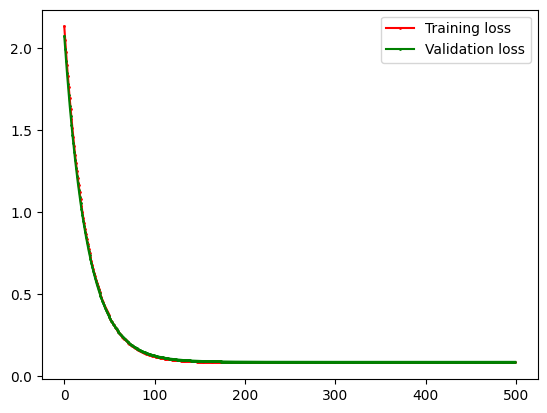

In [88]:
# Train the model
from model.linear_model import LinearModel

seed = 42 # do not change the seed
np.random.seed(seed)

# Setting loss function and gradient.
loss_fn = metrics.MSE
grad_fn = gradients.MSE_grad

# Split dataset to train dataset and validation dataset
X_train,y_train,X_val,y_val = utils.get_train_val(X,y)

# Setting model and starting training
model = LinearModel(dim,True,loss_fn,grad_fn)
model.fit(X_train,y_train,lr=0.01,n_iteration =500,val_ratio=0.2)

In [89]:
# Get the Prediction
y_val_pred = model.predict(X_val)

In [90]:
# Evaluation
# Please complete the evaluate_linear_regression in the model/metrics.py by the sklearn package.
metrics.evaluate_linear_regression(y_true=y_val,y_pred=y_val_pred,title='Linear Regression Evaluation')

=== Linear Regression Evaluation ===
MSE       : 0.0824
MAE       : 0.2467
RMSE      : 0.2870
R-squared : 0.9716


{'MSE': 0.08239259798771861,
 'MAE': 0.24670454246976223,
 'RMSE': np.float64(0.28704110853276504),
 'R-squared': 0.9716055842213308}